## Introduction
This notebook presents the development and evaluation of machine learning models for loan default prediction. Using the Loans Dataset.csv (4,212 records), the goal is to predict whether a loan will be outstanding or defaulted.
The dataset is imbalanced, with approximately 80% outstanding loans and 20% defaulted loans. This reflects a realistic credit risk scenario where accurately identifying the minority class (defaults) is critical for the financial institution.

**Objectives**

- Build and compare classification models (Baseline, SMOTE, and Tuned versions).
- Handle class imbalance using SMOTE (applied only on training data).
- Perform hyperparameter tuning to improve model performance.
- Identify the best model based on appropriate metrics (especially F1-score, Recall, and PR-AUC).
- Provide actionable insights through feature importance (SHAP values).

All experiments follow best practices: train-test splitting before resampling, reproducible workflows, and clear documentation.

## Business Scenario

A local financial institution wants to improve its credit risk assessment process by predicting whether a loan is likely
to default. As a data mining consultant, you have been asked to develop a predictive model that supports early
identification of risky loans. Since defaulted loans are fewer than outstanding loans, the classification problem is im-
balanced. Your task is to compare baseline models with models trained after applying SMOTE and hyperparameter
tuning.

# Import libraries

In [111]:
import pandas as pd 
import numpy as np 

# VISUALIZATION
import matplotlib.pyplot as plt  # Basic plotting library for charts
import seaborn as sns             # Statistical data visualization


# DATA PREPROCESSINGG 
from sklearn.model_selection import (
    train_test_split,      # Splitting dataset into train and test sets
    StratifiedKFold,       # Cross validation preserving class distributio
    GridSearchCV           # Hyperparameta tuning using grid search
)

from sklearn.preprocessing import (
    StandardScaler,        # Feature scaling
    OneHotEncoder          # Convert categorical variables into numericx
)

from sklearn.compose import ColumnTransformer  # Apply different preprocessing to different columns
from sklearn.pipeline import Pipeline           # Build ML pipelines (steps chained together)

# IMBALANCE HANDLING
from imblearn.over_sampling import SMOTE              # Synthetic Minority Oversampling Technique
from imblearn.pipeline import Pipeline as ImbPipeline # Pipeline that supports SMOTE + sklearn models

# MODELS (CLASSIFIERS)
from sklearn.linear_model import LogisticRegression          # Linear classification model
from sklearn.ensemble import RandomForestClassifier         # Tree-based ensemble model
from sklearn.ensemble import GradientBoostingClassifier     # Boosting-based ensemble model
from sklearn.svm import SVC                                 # Support Vector Machine classifier

# EVALUATION METRICS

from sklearn.metrics import (
    confusion_matrix,        # Confusion matrix 
    accuracy_score,          # Overall correctness
    precision_score,         # Precision metric 
    recall_score,            # Sensitivity 
    f1_score,                # Harmonic mean of precision and recall
    roc_auc_score,           # Area under ROC curve
    precision_recall_curve,  # Precision-recall tradeoff curve
    auc,                     # Area under curve (generic)
    classification_report    # Full classification summary
)
# OTHER
import warnings
warnings.filterwarnings("ignore")  # Suppress warnings for cleaner output

# Load dataset

In [280]:
df = pd.read_csv('Loans_Dataset.csv')
df.sample(5)

,Acct_No,Product_id,Branch,created_by,Effective_date,Customer_No,Currency,Customer_Name,maturity_Date,Term_Value,...,Admin_Fees_Paid_So_Far,Repayment_Rate,Guarantor_1,Guarantor_2,Loan_Duration_Days,Interest_Rate_Category,Repayment_Progress,Interest_Rate_Above_Average,Loan_Amount_Category,Loan_Status
768,43030,Business Loans,Namutumba,Ben Godfrey Kiiza,2021-11-22,90001220,UGX,EFULANSI WONAILA,2022-05-10,24,...,0.0,79.0,90001213-TOEPRISTER-NAISANGA,90001216-NORAH ZABINA-MUTESI,169,Medium,0.765833,False,Small,outstanding
318,47620,Agriculture Loans,Kisozi,Kukundakwe Simon Peter,2022-10-05,30203547,UGX,ISINDE AGUSTINE KALULU,2023-10-05,12,...,0.0,76.0,30202406-SOOSI-LAMUSA,--,365,Medium,0.666700,False,Large,defaulted
1393,51609,Business Loans,Sonde,Samuel Okello,2023-06-16,10902014,UGX,JASMINE MUHAMED NAMUJJU,2023-12-16,6,...,0.0,76.0,10901960-BARBRA-APIO,10900972-LYDIA -NABAKABYA,183,Medium,0.166700,True,Large,outstanding
997,49442,Business Loans,Namutumba,Alozius Mulomi,2023-02-02,90002247,UGX,JANIFA BILYERI,2023-08-21,28,...,0.0,56.0,90002321-RUTH-KYABANABWE,90000380-LASIDA-NABIRYE,200,Medium,0.529583,True,Medium,outstanding
522,50146,Agriculture Loans,rwentuha,kasigire bruno,2023-03-13,70100331,ugx,PEACE KYOMUKAMA,2024-01-13,10,...,0.0,65.0,70201151-MILTON- NATU KARUHANGA,70100736-JUSTINAH- RUKUNDO,306,Medium,0.400000,False,Medium,outstanding


# Initial Data Inspection

In [281]:
# number of observations and variables
df.shape

(4212, 29)

In [282]:
# number of observations and variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Acct_No                      4212 non-null   object 
 1   Product_id                   4212 non-null   object 
 2   Branch                       4212 non-null   object 
 3   created_by                   4212 non-null   object 
 4   Effective_date               4212 non-null   object 
 5   Customer_No                  4212 non-null   int64  
 6   Currency                     4212 non-null   object 
 7   Customer_Name                4212 non-null   object 
 8   maturity_Date                4212 non-null   object 
 9   Term_Value                   4212 non-null   int64  
 10  Term_code                    4212 non-null   object 
 11  Disbrsmnt_Setlmnt_Acct_No    4212 non-null   int64  
 12  Loan_Cycle                   4212 non-null   int64  
 13  Ledger_Balance    

#### data types of all variables

# Exploratory Data Analysis

## Number of rows (observations) and columns (variables)

In [283]:
print("Number of Observations:", df.shape[0])
print("Number of Variables:", df.shape[1])

Number of Observations: 4212
Number of Variables: 29


The dataset contains 4,212 observations and 29 variables, indicating a medium-sized structured dataset suitable for classification modeling.

## Data types of all variables

In [284]:
# Display data types of each variable
# Summary of data types and unique values
column_summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
})


print(column_summary)

                         Column Data Type
0                       Acct_No    object
1                    Product_id    object
2                        Branch    object
3                    created_by    object
4                Effective_date    object
5                   Customer_No     int64
6                      Currency    object
7                 Customer_Name    object
8                 maturity_Date    object
9                    Term_Value     int64
10                    Term_code    object
11    Disbrsmnt_Setlmnt_Acct_No     int64
12                   Loan_Cycle     int64
13               Ledger_Balance   float64
14             Total_Disbursemt   float64
15              Cur_Dr_Int_Rate     int64
16                    Int_ Type    object
17            Repayment_Freq_Cd    object
18              Int_paid_so far   float64
19       Admin_Fees_Paid_So_Far   float64
20               Repayment_Rate   float64
21                  Guarantor_1    object
22                  Guarantor_2   


#### **Data Structure Overview**

The dataset contains a mix of numerical, categorical, boolean, and date-related variables.

Most features are properly typed, with:
 - Integer and float types capturing financial and behavioral loan metrics
 - String (object) types representing identifiers, categories, and descriptive fields
 - Boolean type used for binary indicators (e.g., Interest_Rate_Above_Average)

Overall, the dataset structure is well-defined and suitable for further preprocessing,

## Missing values

In [285]:
# Count missing values per column
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

Acct_No                        0
Cur_Dr_Int_Rate                0
Loan_Amount_Category           0
Interest_Rate_Above_Average    0
Repayment_Progress             0
Interest_Rate_Category         0
Loan_Duration_Days             0
Guarantor_2                    0
Guarantor_1                    0
Repayment_Rate                 0
Admin_Fees_Paid_So_Far         0
Int_paid_so far                0
Repayment_Freq_Cd              0
Int_ Type                      0
Total_Disbursemt               0
Product_id                     0
Ledger_Balance                 0
Loan_Cycle                     0
Disbrsmnt_Setlmnt_Acct_No      0
Term_code                      0
Term_Value                     0
maturity_Date                  0
Customer_Name                  0
Currency                       0
Customer_No                    0
Effective_date                 0
created_by                     0
Branch                         0
Loan_Status                    0
dtype: int64

#### **Data Quality Summary:**
- The dataset shows no missing values across all features (0 nulls in every column).
- This suggests strong data completeness, reducing the need for imputation and minimizing risk of bias from missing data handling.

## Target variable distribution

In [286]:
# Count class distribution
df['Loan_Status'].value_counts()

Loan_Status
outstanding    3370
defaulted       842
Name: count, dtype: int64

In [287]:
# Percentage distribution
df['Loan_Status'].value_counts(normalize=True) * 100

Loan_Status
outstanding    80.009497
defaulted      19.990503
Name: proportion, dtype: float64

#### **Summary:**
The target variable is imbalanced, with most loans classified as outstanding (≈80%) and a smaller portion as defaulted (≈20%).

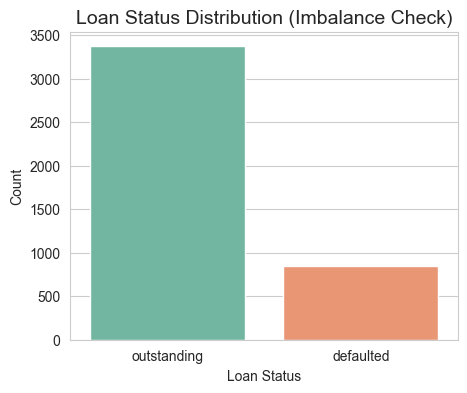

In [288]:
plt.figure(figsize=(5, 4))
# Count plot with color
sns.countplot(x='Loan_Status', data=df, palette='Set2')
# Title with styling
plt.title("Loan Status Distribution (Imbalance Check)", fontsize=14)

plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

- Insight: 20% default rate indicates meaningful credit risk exposure.
- Impact: Class imbalance requires careful model evaluation (recall, F1, ROC-AUC over accuracy).

## Summary Statistics for Numerical Variables

In [289]:
# Summary statistics for numerical variables
df.describe()

,Customer_No,Term_Value,Disbrsmnt_Setlmnt_Acct_No,Loan_Cycle,Ledger_Balance,Total_Disbursemt,Cur_Dr_Int_Rate,Int_paid_so far,Admin_Fees_Paid_So_Far,Repayment_Rate,Loan_Duration_Days,Repayment_Progress
count,4.212000e+03,4212.000000,4.212000e+03,4212.000000,4.212000e+03,4.212000e+03,4212.000000,4.212000e+03,4212.000000,4212.000000,4212.000000,4212.000000
mean,5.324611e+07,17.130342,5.324611e+11,2.396724,1.137229e+06,2.013449e+06,37.442308,3.559191e+05,884.135066,74.549622,253.757123,0.475867
std,2.504985e+07,8.884700,2.504985e+11,1.524912,3.248013e+06,4.470304e+06,3.659355,1.181858e+06,10713.432437,12.728848,136.427745,0.289765
min,1.010005e+07,1.000000,1.010005e+11,1.000000,2.224900e+02,2.000000e+05,12.000000,0.000000e+00,0.000000,50.000000,31.000000,0.000000
25%,3.050177e+07,10.000000,3.050177e+11,1.000000,2.412922e+05,6.000000e+05,36.000000,5.740000e+04,0.000000,70.000000,174.000000,0.215888
50%,6.020238e+07,12.000000,6.020238e+11,2.000000,5.000000e+05,1.000000e+06,39.000000,1.260000e+05,0.000000,76.000000,200.000000,0.500000
75%,7.050069e+07,24.000000,7.050069e+11,3.000000,1.000000e+06,2.000000e+06,39.000000,2.866500e+05,0.000000,82.000000,305.000000,0.721645
max,9.000244e+07,60.000000,9.000244e+11,14.000000,9.166660e+07,1.000000e+08,120.000000,3.000000e+07,255285.000000,96.000000,1851.000000,0.999852


#### **Key insights:**

- A few very large loans distort the portfolio, but most lending activity is concentrated in smaller retail/SME loans.

- Pricing is strongly risk-based and highly volatile, suggesting a high-risk borrower base or aggressive risk pricing strategy.

- While most loans are performing, repayment is not consistently strong, leaving a meaningful risk gap in the portfolio.

- Most borrowers are still in early borrowing stages, meaning customer relationships are not yet mature and retention is still developing.

- The portfolio is dominated by higher-risk pricing tiers, indicating either a risk-heavy customer base or conservative underwriting.

### Distribution of Numerical Variables (visual)
#### Check skewness & outliers.

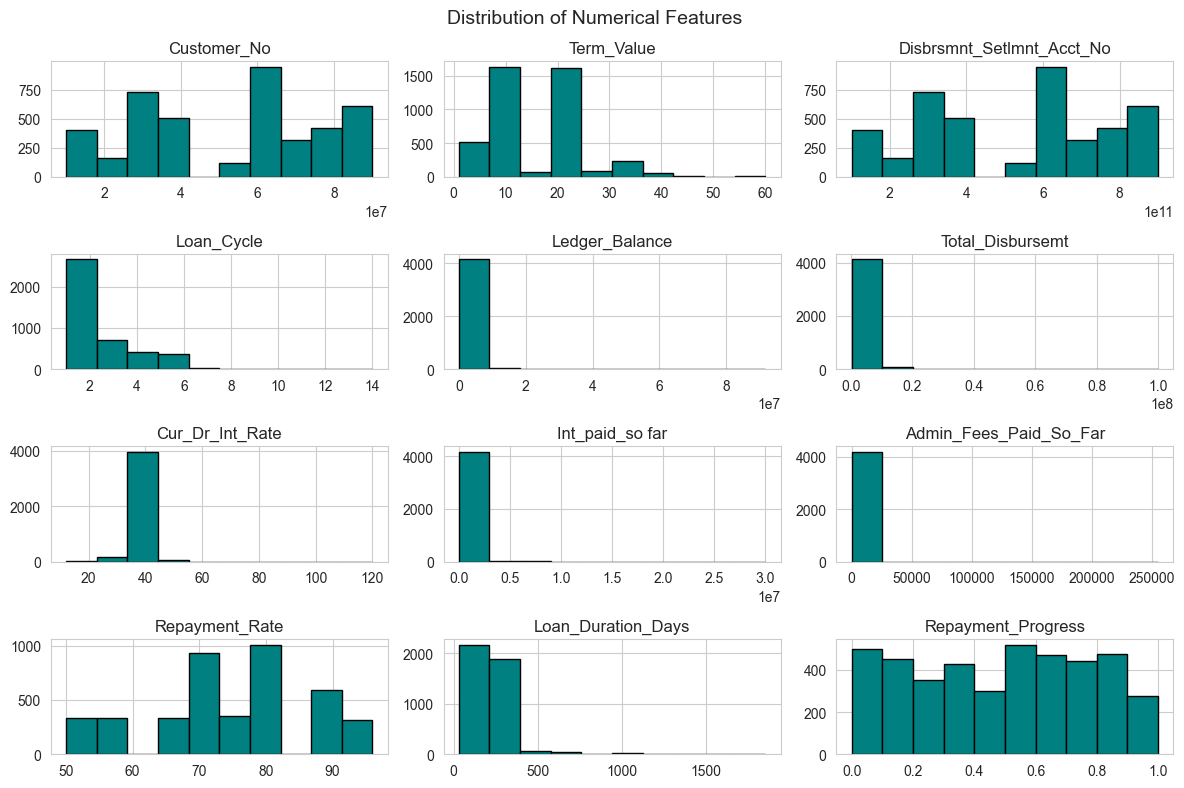

In [290]:
# Histogram of all numerical variables with styling
df.hist(figsize=(12, 8), color='teal', edgecolor='black')

plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

#### **Key insights:**
Most numerical features are highly skewed with strong right tails, meaning a small number of customers/loans have extremely large values (e.g., disbursement, balances, fees), while most observations are concentrated at lower values.

## Frequency distributions for selected categorical variables

### 1. Frequency Distribution of Loan Branches

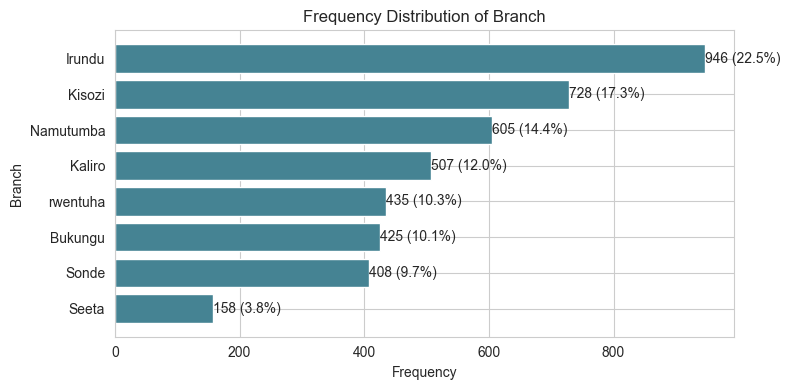

In [291]:
summary = df['Branch'].value_counts().reset_index()
summary.columns = ['Branch', 'Count']
summary['Percentage'] = (summary['Count'] / len(df) * 100).round(2)

# Sort for better visualization
summary = summary.sort_values('Count', ascending=True)

bar_color = '#458393'

plt.figure(figsize=(8, 4))

bars = plt.barh(
    summary['Branch'].astype(str),
    summary['Count'],
    color=bar_color
)

# labels
for bar, count, pct in zip(bars, summary['Count'], summary['Percentage']):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'{count} ({pct:.1f}%)',
        va='center',
        ha='left'
    )

plt.title('Frequency Distribution of Branch')
plt.xlabel('Frequency')
plt.ylabel('Branch')

plt.tight_layout()
plt.show()

Most loans are concentrated in a few branches, with Irundu (22%) leading, followed by Kisozi and Namutumba, while Seeta contributes very little (4%), indicating uneven branch performance or reach.

### 2. Frequency Distribution of Loan Products

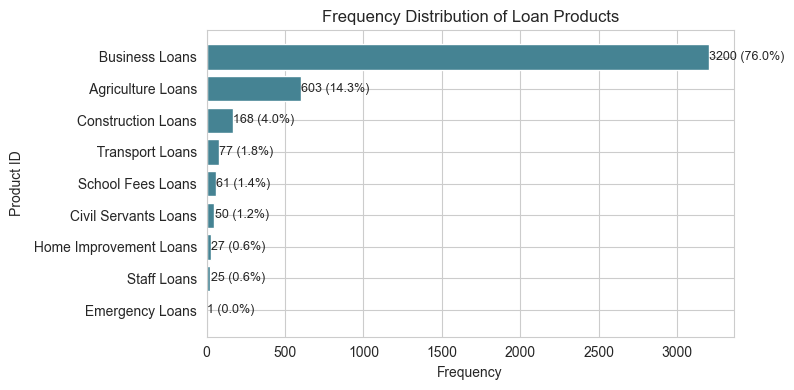

In [292]:
summary = df['Product_id'].value_counts().reset_index()
summary.columns = ['Product_id', 'Count']
summary['Percentage'] = (summary['Count'] / len(df) * 100).round(2)

plt.figure(figsize=(8,4))

bar_color = '#458393'

bars = plt.barh(
    summary['Product_id'].astype(str),
    summary['Count'],
    color=bar_color
)

# Add count and percentage labels
for bar, count, pct in zip(bars, summary['Count'], summary['Percentage']):
    plt.text(
        bar.get_width() + 2,                    # Place text just outside the bar
        bar.get_y() + bar.get_height()/2,
        f'{count} ({pct:.1f}%)',
        va='center',
        fontsize=9
    )

plt.title('Frequency Distribution of Loan Products')
plt.xlabel('Frequency')
plt.ylabel('Product ID')

# Optional: Highest frequency at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Business Loans dominate the portfolio at about 76%, meaning the institution is heavily exposed to business lending, with all other loan types individually contributing less than 15%.

### Frequency Distribution of Repayment Frequency Categories

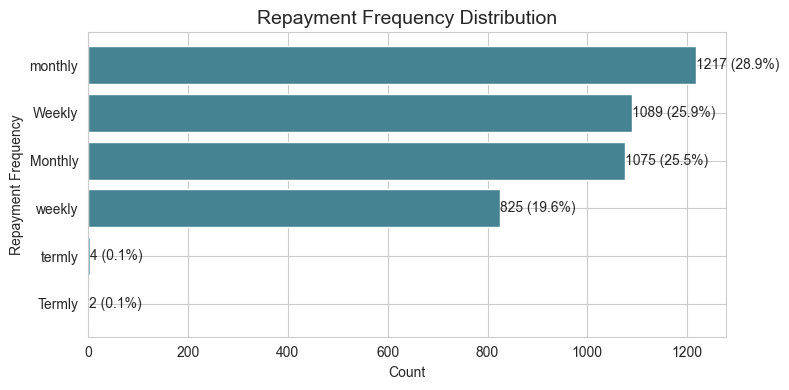

In [293]:
summary = df['Repayment_Freq_Cd'].value_counts().reset_index()
summary.columns = ['Repayment_Freq_Cd', 'Count']
summary['Percentage'] = (summary['Count'] / len(df) * 100).round(2)

# Sort for better readability
summary = summary.sort_values('Count', ascending=True)

plt.figure(figsize=(8, 4))

bars = plt.barh(
    summary['Repayment_Freq_Cd'].astype(str),
    summary['Count'],
    color='#458393'
)

for bar, count, pct in zip(bars, summary['Count'], summary['Percentage']):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'{count} ({pct:.1f}%)',
        va='center',
        ha='left'
    )

plt.title('Repayment Frequency Distribution', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Repayment Frequency')

plt.tight_layout()
plt.show()

Repayment frequency data shows inconsistencies (e.g., “monthly” vs “Monthly”, “weekly” vs “Weekly”), but overall monthly and weekly repayment plans dominate, making up the vast majority of borrowers.

### Frequency Distribution of Loan Amount Categories

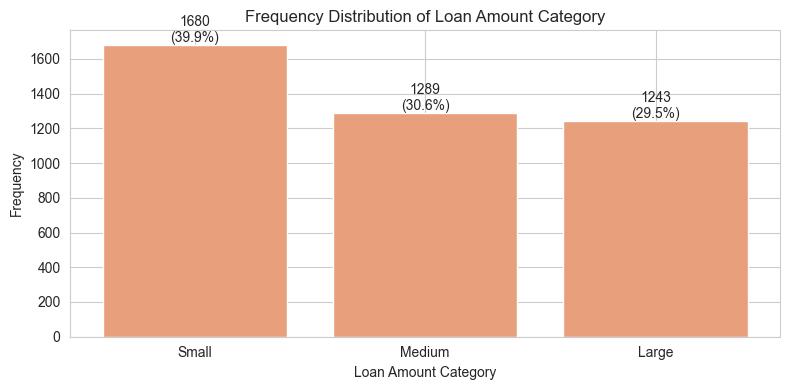

In [294]:
summary = df['Loan_Amount_Category'].value_counts().reset_index()
summary.columns = ['Loan_Amount_Category', 'Count']
summary['Percentage'] = (summary['Count'] / len(df) * 100).round(2)

plt.figure(figsize=(8,4))

bars = plt.bar(
    summary['Loan_Amount_Category'].astype(str),
    summary['Count'],
    color='#E8A07C'  
)

for bar, count, pct in zip(bars, summary['Count'], summary['Percentage']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{count}\n({pct:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.title('Frequency Distribution of Loan Amount Category')
plt.xlabel('Loan Amount Category')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Loan sizes are fairly balanced but slightly skewed toward Small loans (40%), followed by Medium (31%) and Large (30%), suggesting a diversified but slightly lower-value loan book.

#### **Key insights:**
Overall, the portfolio is concentrated in business lending and a few key branches, with mostly small-to-medium loans and frequent short-term repayment structures.

## visualizations comparing defaulted and outstanding loans

### BAR CHART: LOAN STATUS DISTRIBUTION

In [295]:
# Map loan status labels to binary values
# 1 = Defaulted, 0 = Outstanding

df['Loan_Status'] = df['Loan_Status'].map({
    'defaulted': 1,
    'outstanding': 0
})

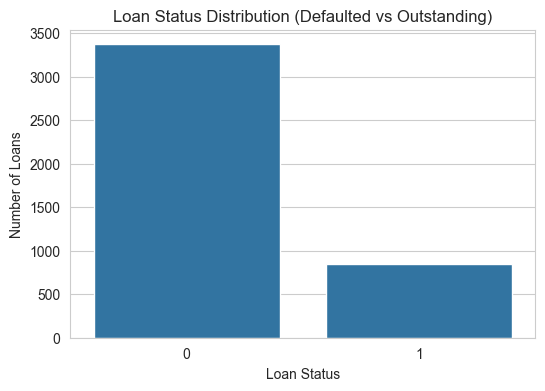

In [296]:
plt.figure(figsize=(6,4))

# Countplot shows frequency of each class
sns.countplot(x='Loan_Status', data=df)

# Add title and labels
plt.title("Loan Status Distribution (Defaulted vs Outstanding)")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")

plt.show()

## default rate by Product id

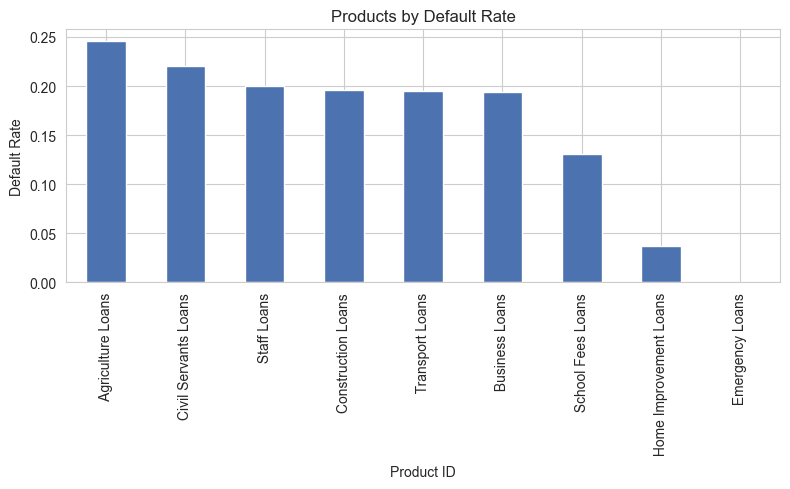

In [297]:
plt.figure(figsize=(8,5))

top10_products.plot(
    kind='bar',
    color='#4C72B0'
)

plt.title("Products by Default Rate")
plt.xlabel("Product ID")
plt.ylabel("Default Rate")
plt.tight_layout()
plt.show()

#### **Key insights:**
Agriculture Loans have the highest default rate (24.5%), followed by Civil Servants and Staff Loans, indicating higher risk in these segments. Construction, Transport, and Business Loans sit in a moderate risk range (19–20%).

School Fees Loans show relatively lower default (13%), while Home Improvement Loans are very low (3.7%). Emergency Loans show 0% default, but this could also mean very low sample size.

Overall, higher-risk lending is concentrated in agriculture and some employment-linked loans, while smaller or purpose-specific loans like home improvement appear more stable.

## default rate by Branch

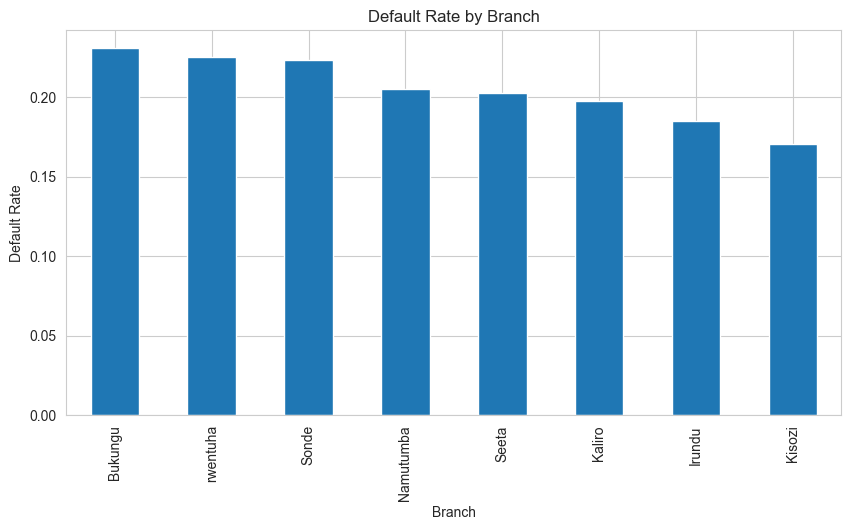

In [298]:
branch_default_rate = (
    df.groupby('Branch')['Loan_Status']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
branch_default_rate.plot(kind='bar')

plt.title("Default Rate by Branch")
plt.xlabel("Branch")
plt.ylabel("Default Rate")

plt.show()

#### **Key insights:**
Bukungu has the highest default rate (23.1%), followed closely by Rwentuha and Sonde, indicating these branches are carrying higher credit risk.

Mid-range branches like Namutumba, Seeta, and Kaliro sit around 19–20% default, showing moderate risk levels.

Irundu and Kisozi perform better comparatively, with the lowest default rates (18.5% and 17%), meaning they have healthier loan repayment behavior.

Overall, the risk is uneven across branches, with a few branches (especially Bukungu, Rwentuha, Sonde) driving higher credit losses and needing closer credit control or tighter lending standards.

### Total Disbursemt VS Loan Status

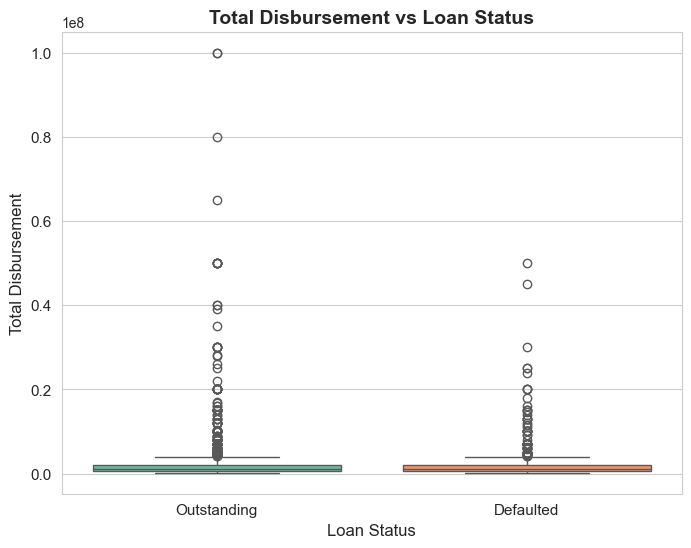

In [299]:

df['Loan_Status_Label'] = df['Loan_Status'].map({
    0: 'Outstanding',
    1: 'Defaulted'
})

# Improve style
sns.set_style("whitegrid")

plt.figure(figsize=(8,6))

# Boxplot with better visibility
sns.boxplot(
    x='Loan_Status_Label',
    y='Total_Disbursemt',
    data=df,
    palette="Set2"
)

plt.title("Total Disbursement vs Loan Status", fontsize=14, fontweight='bold')
plt.xlabel("Loan Status", fontsize=12)
plt.ylabel("Total Disbursement", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

- The average loan size is almost the same for both groups (~2.0M UGX for outstanding vs ~2.05M UGX for defaulted), meaning loan size alone is not a strong separator of default risk.
- The median is identical (1,000,000 UGX) for both, showing most loans are clustered around smaller loan values.
- However, defaulted loans show slightly lower variability (std ~3.72M vs ~4.64M) and a lower maximum (50M vs 100M), suggesting fewer extreme high-value loans in defaults.

### Repayment Progress by Loan Status

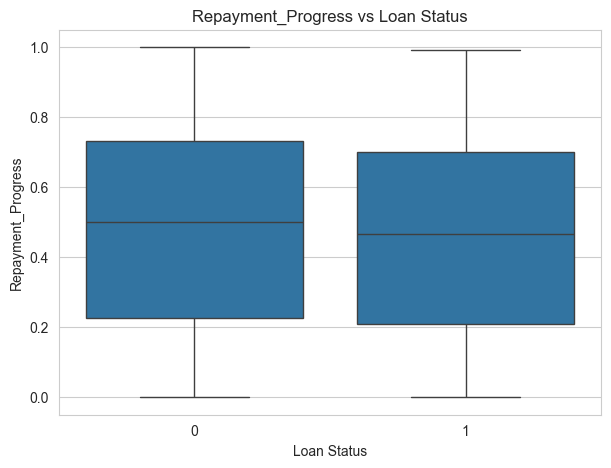

In [132]:
# Boxplot compares distribution of loan amounts across classes

plt.figure(figsize=(7,5))

sns.boxplot(x='Loan_Status', y='Repayment_Progress', data=df)

plt.title("Repayment_Progress vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Repayment_Progress")

plt.show()

#### **Key insights:**
Both groups show very similar behavior, with mean repayment progress around 48% (Outstanding) and 46% (Defaulted).
The medians are also close (50% vs 46.5%), meaning half of borrowers in both groups are roughly halfway through repayment.
The spread is almost identical, showing high variability in repayment behavior across both groups.
Even the maximum values are nearly the same (~99%), meaning some defaulted customers had almost fully repaid before defaulting.

## correlation heatmap

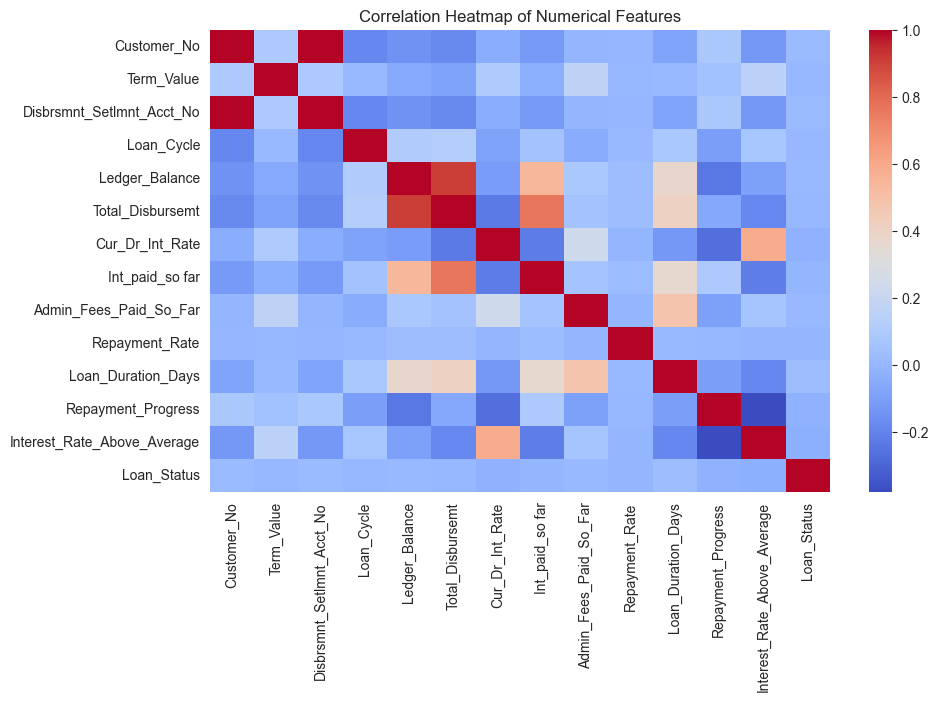

In [300]:
# Compute correlation matrix for numerical variables
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(corr, cmap='coolwarm', annot=False)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

#### **Key insights:**
- Strongest relationship in the dataset is financial scale linkage
- Interest rate strongly affects pricing behavior but not repayment outcome directly
- Repayment Progress is negatively linked to risk indicators
- Loan size and activity are moderately connected to loan duration
- Loan_Status has almost no strong linear relationships with any variable
Overall takeaway:

The dataset is highly interconnected financially (disbursement, interest, balance), but loan default is not strongly explained by any single numeric variable, suggesting the need for multi-variable or machine learning models instead of simple linear analysis.

# Data Preprocessing

### COPY DATASET (SAFE WORKING COPY)

In [301]:

# This ensures original data remains unchanged for reproducibility
df_model = df.copy()

### Drop identifier-like columns

In [302]:
# Drop identifier-like columns that do not contribute to prediction

drop_cols = [
    'Acct_No',
    'Customer_No',
    'Customer_Name',
    'Loan_Status_Label',
    'Disbrsmnt_Setlmnt_Acct_No',
    'created_by',   # system/user identifier
    'Guarantor_1',  # identity-related field
    'Guarantor_2'   # identity-related field

]

# Remove only columns that exist in dataset
df_model.drop(columns=[col for col in drop_cols if col in df_model.columns], inplace=True)

df_model.head()

,Product_id,Branch,Effective_date,Currency,maturity_Date,Term_Value,Term_code,Loan_Cycle,Ledger_Balance,Total_Disbursemt,...,Repayment_Freq_Cd,Int_paid_so far,Admin_Fees_Paid_So_Far,Repayment_Rate,Loan_Duration_Days,Interest_Rate_Category,Repayment_Progress,Interest_Rate_Above_Average,Loan_Amount_Category,Loan_Status
0,Agriculture Loans,Namutumba,2022-06-02,UGX,2023-03-31,10,Months,2,1755550.00,3000000.0,...,Monthly,900000.0,0.0,70.0,302,Medium,0.414817,False,Large,0
1,Agriculture Loans,Namutumba,2022-07-20,UGX,2023-05-20,10,Months,2,378152.13,3000000.0,...,Monthly,900000.0,0.0,90.0,304,Medium,0.873949,False,Large,0
2,Agriculture Loans,Namutumba,2022-07-21,UGX,2023-01-18,6,Months,1,52300.00,2000000.0,...,Monthly,360000.0,0.0,70.0,181,Medium,0.973850,False,Large,0
3,Agriculture Loans,Namutumba,2022-08-16,UGX,2023-06-14,10,Months,2,761050.00,1500000.0,...,Monthly,450000.0,0.0,50.0,302,Medium,0.492633,False,Medium,0
4,Agriculture Loans,Namutumba,2022-08-30,UGX,2023-02-18,24,Weeks,3,243200.00,1500000.0,...,Weekly,270000.0,0.0,70.0,172,Medium,0.837867,False,Medium,0


## Standardize the values

#### Term_code

In [303]:

# Convert to lowercase and remove extra spaces
df_model['Term_code'] = df_model['Term_code'].str.strip().str.lower()

# Standardize values
df_model['Term_code'] = df_model['Term_code'].replace({
    'month': 'months',
    'months': 'months',
    'week': 'weeks',
    'weeks': 'weeks',
    'term': 'term',
    'terms': 'term'
})

In [304]:
#Remove extra spaces
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = df_model[col].str.strip()

In [305]:
df_model.columns = df_model.columns.str.replace(' ', '_')

###  CONVERT DATE VARIABLES INTO FEATURES

In [306]:
# Convert to datetime format

df_model['Effective_date'] = pd.to_datetime(df_model['Effective_date'])
df_model['maturity_Date'] = pd.to_datetime(df_model['maturity_Date'])

# Feature engineering from dates

# Loan duration in days
df_model['loan_duration_days'] = (df_model['maturity_Date'] - df_model['Effective_date']).dt.days

# Extract time-based patterns
df_model['loan_start_year'] = df_model['Effective_date'].dt.year
df_model['loan_start_month'] = df_model['Effective_date'].dt.month

# Drop original date columns (no longer needed)
df_model.drop(columns=['Effective_date', 'maturity_Date'], inplace=True)


In [307]:
# Define categorical (nominal) variables
nominal_cols = [
    'Product_id',
    'Branch',
    'Repayment_Freq_Cd',
    'Currency',
    'Int__Type'
]

df_model = pd.get_dummies(
    df_model,
    columns=nominal_cols,
    drop_first=True
)

#### Ordinal Encode

In [308]:
loan_map = {
    'Small':0,
    'Medium':1,
    'Large':2
}

df_model['Loan_Amount_Category'] = df_model['Loan_Amount_Category'].map(loan_map)

In [309]:
loan_map = {
    'Low':0,
    'Medium':1,
    'High':2
}

df_model['Interest_Rate_Category'] = df_model['Interest_Rate_Category'].map(loan_map)

### One-Hot Encode Term_code

In [310]:
df_model = pd.get_dummies(
    df_model,
    columns=['Term_code'],
    drop_first=False
)

### DATASET STRUCTURE COMPARISON TABLE

In [145]:
comparison_table = pd.DataFrame({
    "Original Dataset (df)": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.select_dtypes(include='object').shape[1],
        df.select_dtypes(include='number').shape[1]
    ],
    "Model Dataset (df_model)": [
        df_model.shape[0],
        df_model.shape[1],
        df_model.isnull().sum().sum(),
        df_model.select_dtypes(include='object').shape[1],
        df_model.select_dtypes(include='number').shape[1]
    ]
}, index=[
    "Rows",
    "Columns",
    "Total Missing Values",
    "Categorical Columns",
    "Numerical Columns"
])

comparison_table

,Original Dataset (df),Model Dataset (df_model)
Rows,4212,4212
Columns,30,42
Total Missing Values,0,0
Categorical Columns,16,0
Numerical Columns,13,16


## Stratified Train-Test Split

In [146]:
X = df_model.drop('Loan_Status', axis=1)
y = df_model['Loan_Status']

In [147]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,          # 80% train, 20% test
    random_state=42,        # reproducibility
    stratify=y              
)

#### Verify Class Distribution

In [148]:
dist_table = pd.DataFrame({
    "Overall (%)": y.value_counts(normalize=True) * 100,
    "Train (%)": y_train.value_counts(normalize=True) * 100,
    "Test (%)": y_test.value_counts(normalize=True) * 100
})

# Round for readability
dist_table = dist_table.round(2)

dist_table

,Overall (%),Train (%),Test (%)
Loan_Status,,,
0,80.01,80.02,79.95
1,19.99,19.98,20.05


This table shows how the loan classes are distributed across the full dataset, training set, and test set.

About 80% of loans are Outstanding (0) and 20% are Defaulted (1) in the full data.
The training and test sets keep almost the same proportions, with only tiny differences.
This means the data was split correctly using stratified sampling, so both sets fairly represent the original dataset.

## Baseline Classification Models

### Reusable Evaluation Function - FUNCTION TO TRAIN AND EVALUATE A CLASSIFICATION MODEL

In [180]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Train the model
    model.fit(X_train, y_train)
    # Generate predictions 

    y_pred = model.predict(X_test)
    # Obtain prediction probabilities


    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]

    else:
        y_prob = model.decision_function(X_test)


    # metrics calculationn 


    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    precision_vals, recall_vals, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    pr_auc = auc(
        recall_vals,
        precision_vals
    )
    # Confusion Matrix


    fig, ax = plt.subplots(figsize=(5,4))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues",
        ax=ax
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.show()


    # Metrics
    print(f"\n{'='*60}")
    print(model_name)
    print(f"{'='*60}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")
    
    return {

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "ROC-AUC": roc_auc,

        "PR-AUC": pr_auc

    }

### Define Baseline Models

In [181]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

gb = GradientBoostingClassifier(
    random_state=42
)

svm = SVC(
    probability=True,
    random_state=42
)

### Train All Baseline Models

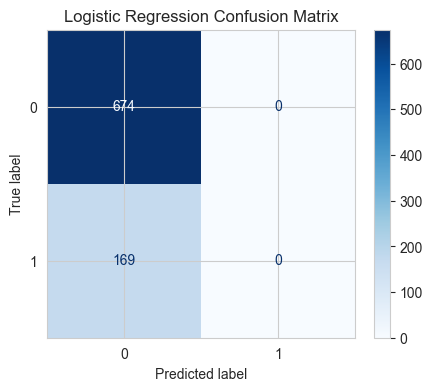


Logistic Regression
Accuracy : 0.7995
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.5262
PR-AUC   : 0.2160


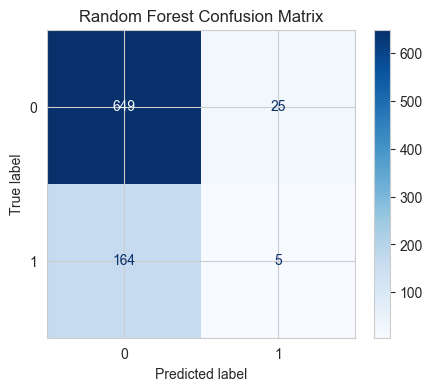


Random Forest
Accuracy : 0.7758
Precision: 0.1667
Recall   : 0.0296
F1 Score : 0.0503
ROC-AUC  : 0.4919
PR-AUC   : 0.1932


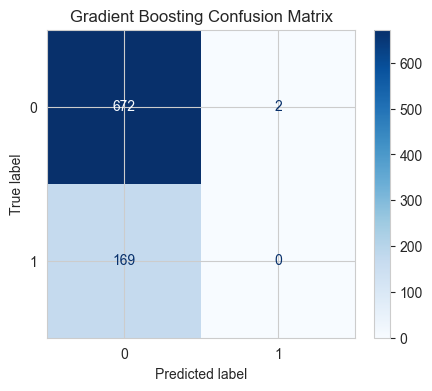


Gradient Boosting
Accuracy : 0.7972
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.5447
PR-AUC   : 0.2309


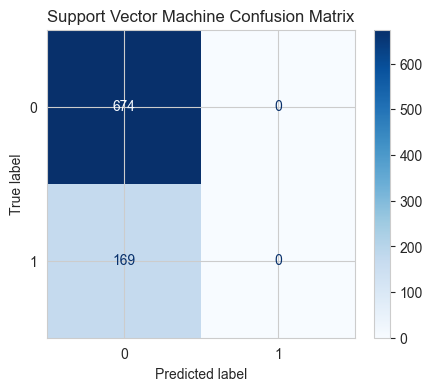


Support Vector Machine
Accuracy : 0.7995
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.4732
PR-AUC   : 0.1932


In [182]:
baseline_results = []

baseline_results.append(
    evaluate_model(
        log_reg,
        X_train,
        X_test,
        y_train,
        y_test,
        "Logistic Regression"
    )
)

baseline_results.append(
    evaluate_model(
        rf,
        X_train,
        X_test,
        y_train,
        y_test,
        "Random Forest"
    )
)

baseline_results.append(
    evaluate_model(
        gb,
        X_train,
        X_test,
        y_train,
        y_test,
        "Gradient Boosting"
    )
)

baseline_results.append(
    evaluate_model(
        svm,
        X_train,
        X_test,
        y_train,
        y_test,
        "Support Vector Machine"
    )
)

### Baseline Model Comparison Table

In [183]:
baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df = baseline_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

baseline_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,Gradient Boosting,0.7972,0.0000,0.0000,0.0000,0.5447,0.2309
0,Logistic Regression,0.7995,0.0000,0.0000,0.0000,0.5262,0.2160
1,Random Forest,0.7758,0.1667,0.0296,0.0503,0.4919,0.1932
3,Support Vector Machine,0.7995,0.0000,0.0000,0.0000,0.4732,0.1932


- **Severe Class Imbalance Issue**: Models achieved ~78–80% accuracy but failed to detect the positive class (Precision, Recall & F1 near zero for most models). This indicates the models are simply predicting the majority class.

**Poor Minority Class Performance**:
- Random Forest showed minimal detection (Recall = 0.0296, F1 = 0.0503).
- Gradient Boosting, Logistic Regression, and SVM had zero ability to identify positive cases.

- Weak Discrimination: ROC-AUC (~0.47–0.54) is only marginally better than random guessing. PR-AUC (0.19–0.23) confirms very poor performance on the rare class.

- **Random Forest** performed best among the tested models, but still insufficient for practical use.


## Class Balancing Using SMOTE

In [186]:
#distribution 
print("Training Set Class Distribution (Before SMOTE)")
print(Counter(y_train))

Training Set Class Distribution (Before SMOTE)
Counter({0: 2696, 1: 673})


The training dataset is highly imbalanced, with outstanding loans (Class 0) greatly outnumbering defaulted loans (Class 1). This imbalance can bias machine learning models towards predicting the majority class.

### Apply SMOTE to the Training Set

In [187]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

The actual models will use SMOTE inside a pipeline

### Show Class Distribution After SMOTE

In [188]:
print("Training Set Class Distribution (After SMOTE)")
print(Counter(y_train_smote))

Training Set Class Distribution (After SMOTE)
Counter({0: 2696, 1: 2696})


### Before vs After SMOTE Table

In [189]:
distribution = pd.DataFrame({
    "Before SMOTE": pd.Series(Counter(y_train)),
    "After SMOTE": pd.Series(Counter(y_train_smote))
})

distribution.index = ["Outstanding (0)", "Defaulted (1)"]

distribution

,Before SMOTE,After SMOTE
Outstanding (0),2696,2696
Defaulted (1),673,2696


### Create SMOTE Pipelines

In [191]:
log_reg_pipe = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

rf_pipe = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

gb_pipe = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

svm_pipe = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(
        probability=True,
        random_state=42
    ))
])

### Train the SMOTE Models

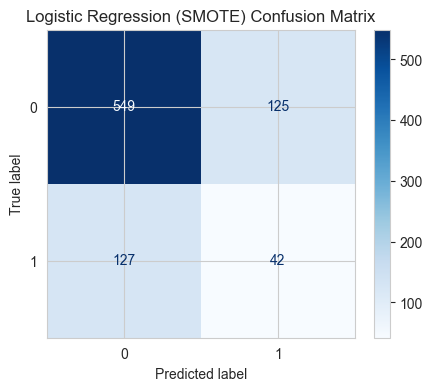


Logistic Regression (SMOTE)
Accuracy : 0.7011
Precision: 0.2515
Recall   : 0.2485
F1 Score : 0.2500
ROC-AUC  : 0.5518
PR-AUC   : 0.2328


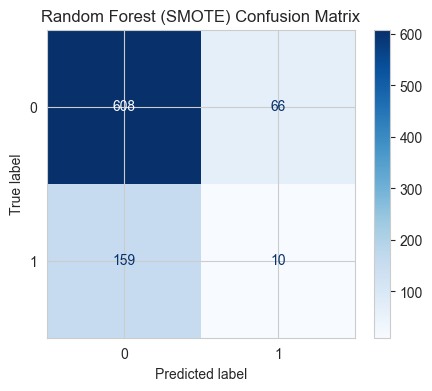


Random Forest (SMOTE)
Accuracy : 0.7331
Precision: 0.1316
Recall   : 0.0592
F1 Score : 0.0816
ROC-AUC  : 0.4978
PR-AUC   : 0.1956


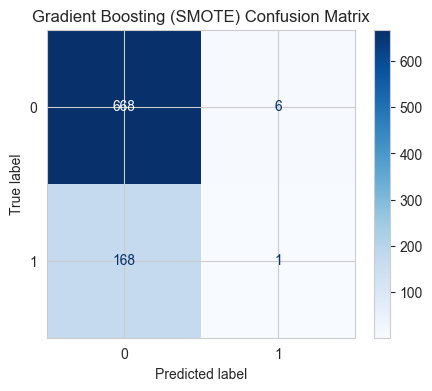


Gradient Boosting (SMOTE)
Accuracy : 0.7936
Precision: 0.1429
Recall   : 0.0059
F1 Score : 0.0114
ROC-AUC  : 0.5068
PR-AUC   : 0.2114


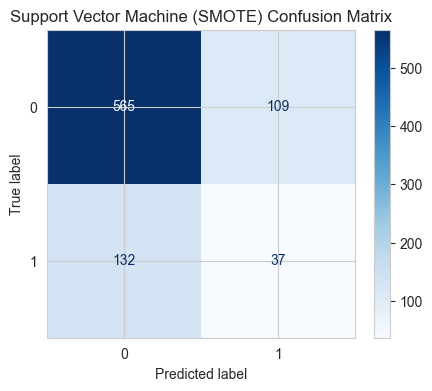


Support Vector Machine (SMOTE)
Accuracy : 0.7141
Precision: 0.2534
Recall   : 0.2189
F1 Score : 0.2349
ROC-AUC  : 0.5514
PR-AUC   : 0.2371


In [192]:
smote_results = []

smote_results.append(
    evaluate_model(
        log_reg_pipe,
        X_train,
        X_test,
        y_train,
        y_test,
        "Logistic Regression (SMOTE)"
    )
)

smote_results.append(
    evaluate_model(
        rf_pipe,
        X_train,
        X_test,
        y_train,
        y_test,
        "Random Forest (SMOTE)"
    )
)

smote_results.append(
    evaluate_model(
        gb_pipe,
        X_train,
        X_test,
        y_train,
        y_test,
        "Gradient Boosting (SMOTE)"
    )
)

smote_results.append(
    evaluate_model(
        svm_pipe,
        X_train,
        X_test,
        y_train,
        y_test,
        "Support Vector Machine (SMOTE)"
    )
)

### SMOTE Results Table

In [193]:
smote_results_df = pd.DataFrame(smote_results)

smote_results_df = smote_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

smote_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression (SMOTE),0.7011,0.2515,0.2485,0.2500,0.5518,0.2328
3,Support Vector Machine (SMOTE),0.7141,0.2534,0.2189,0.2349,0.5514,0.2371
2,Gradient Boosting (SMOTE),0.7936,0.1429,0.0059,0.0114,0.5068,0.2114
1,Random Forest (SMOTE),0.7331,0.1316,0.0592,0.0816,0.4978,0.1956


**Key Insights (SMOTE Results):**

- SMOTE improved minority class detection compared to previous runs, but overall performance remains weak.
- Logistic Regression (SMOTE) performed best with balanced Precision/Recall (~0.25) and highest F1 score (0.2500).
- Support Vector Machine (SMOTE) came in second with decent Recall.
- Gradient Boosting deteriorated significantly after SMOTE (Recall dropped to 0.0059).
- Random Forest showed only marginal improvement.
- F1 scores still very low (< 0.26) across all models → limited practical value.
- Accuracy dropped as expected when prioritizing the minority class.
- PR-AUC remains low (0.19–0.24), indicating poor positive class prediction.

### Compare Baseline vs SMOTE

In [194]:
baseline = baseline_results_df.copy()
baseline["Data"] = "Before SMOTE"

smote = smote_results_df.copy()
smote["Data"] = "After SMOTE"

comparison = pd.concat(
    [baseline, smote],
    ignore_index=True
)

comparison = comparison[[
    "Model",
    "Data",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]]

comparison.round(4)

,Model,Data,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Gradient Boosting,Before SMOTE,0.7972,0.0000,0.0000,0.0000,0.5447,0.2309
1,Logistic Regression,Before SMOTE,0.7995,0.0000,0.0000,0.0000,0.5262,0.2160
2,Random Forest,Before SMOTE,0.7758,0.1667,0.0296,0.0503,0.4919,0.1932
3,Support Vector Machine,Before SMOTE,0.7995,0.0000,0.0000,0.0000,0.4732,0.1932
4,Logistic Regression (SMOTE),After SMOTE,0.7011,0.2515,0.2485,0.2500,0.5518,0.2328
5,Support Vector Machine (SMOTE),After SMOTE,0.7141,0.2534,0.2189,0.2349,0.5514,0.2371
6,Gradient Boosting (SMOTE),After SMOTE,0.7936,0.1429,0.0059,0.0114,0.5068,0.2114
7,Random Forest (SMOTE),After SMOTE,0.7331,0.1316,0.0592,0.0816,0.4978,0.1956


**Key Insights (Before vs After SMOTE)**

- SMOTE helped Logistic Regression and SVM significantly — both showed big gains in Recall and F1 scores.
- Logistic Regression (SMOTE) is the best performing model overall (F1 = 0.2500, balanced Precision/Recall).
- Gradient Boosting performed worse after SMOTE (Recall collapsed to 0.0059).
- Random Forest improved slightly but remains weak.
- All models still suffer from low F1 scores (max 0.25), indicating limited ability to reliably detect the positive class.
- ROC-AUC improved slightly for top models, but PR-AUC remains low across the board.
- Accuracy dropped for most models after SMOTE — this is expected and acceptable when addressing imbalance.

**Main Takeaway:**

SMOTE brought some improvement, especially for Logistic Regression, but performance is still insufficient for production use. Further techniques (hyperparameter tuning, XGBoost, better sampling, or ensemble methods) are needed.

## Hyperparameter Tuning

### Stratified Cross Validation

In [197]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Logistic Regression Tuning

In [196]:
log_reg_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

log_reg_gs = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=log_reg_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

log_reg_gs.fit(X_train, y_train)

print("Best Logistic Regression Params:", log_reg_gs.best_params_)
print("Best CV F1 Score:", log_reg_gs.best_score_)

Best Logistic Regression Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 Score: 0.0


### Random Forest Tuning

In [198]:
rf_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "class_weight": [None, "balanced"]
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

rf_gs.fit(X_train, y_train)

print("Best Random Forest Params:", rf_gs.best_params_)
print("Best CV F1 Score:", rf_gs.best_score_)

Best Random Forest Params: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}
Best CV F1 Score: 0.25954761983460306


### Gradient Boosting Tuning

In [199]:
gb_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [2, 3, 5],
    "subsample": [0.8, 1.0]
}

gb_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gb_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

gb_gs.fit(X_train, y_train)

print("Best Gradient Boosting Params:", gb_gs.best_params_)
print("Best CV F1 Score:", gb_gs.best_score_)

Best Gradient Boosting Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1 Score: 0.10435229655417969


### Evaluate Tuned Models on Test Set

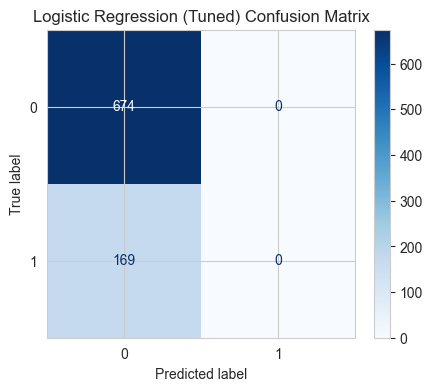


Logistic Regression (Tuned)
Accuracy : 0.7995
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.5262
PR-AUC   : 0.2161


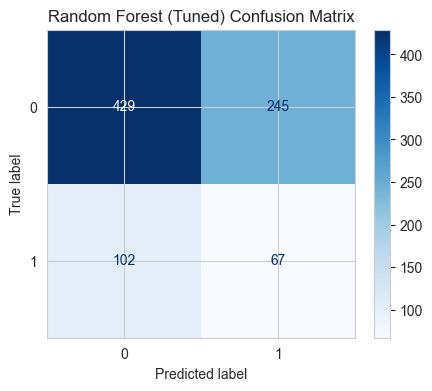


Random Forest (Tuned)
Accuracy : 0.5884
Precision: 0.2147
Recall   : 0.3964
F1 Score : 0.2786
ROC-AUC  : 0.5284
PR-AUC   : 0.2260


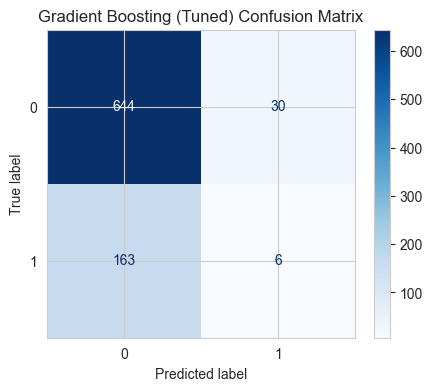


Gradient Boosting (Tuned)
Accuracy : 0.7711
Precision: 0.1667
Recall   : 0.0355
F1 Score : 0.0585
ROC-AUC  : 0.5055
PR-AUC   : 0.2029


In [200]:
tuned_results = []

tuned_results.append(
    evaluate_model(
        log_reg_gs.best_estimator_,
        X_train, X_test, y_train, y_test,
        "Logistic Regression (Tuned)"
    )
)

tuned_results.append(
    evaluate_model(
        rf_gs.best_estimator_,
        X_train, X_test, y_train, y_test,
        "Random Forest (Tuned)"
    )
)

tuned_results.append(
    evaluate_model(
        gb_gs.best_estimator_,
        X_train, X_test, y_train, y_test,
        "Gradient Boosting (Tuned)"
    )
)

### Tuned Model Comparison Table

In [201]:
tuned_df = pd.DataFrame(tuned_results)

tuned_df = tuned_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

tuned_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
1,Random Forest (Tuned),0.5884,0.2147,0.3964,0.2786,0.5284,0.2260
0,Logistic Regression (Tuned),0.7995,0.0000,0.0000,0.0000,0.5262,0.2161
2,Gradient Boosting (Tuned),0.7711,0.1667,0.0355,0.0585,0.5055,0.2029


**Key Insights (Tuned Models):**

- Random Forest (Tuned) is clearly the best model here — significant improvement in Recall (0.3964) and F1 (0.2786), showing much better ability to detect the positive class.
- Trade-off: Accuracy dropped to 0.5884 (expected when improving minority class performance).
- Logistic Regression (Tuned) showed no improvement — still completely failing to predict positives (0.0000 across Precision/Recall/F1).
- Gradient Boosting (Tuned) only had marginal gains and remains weak.
  
Overall, tuning helped Random Forest substantially, but F1 score (0.2786) is still relatively low.
PR-AUC remains poor (~0.20–0.23) across all models.

## Full Model Comparison BASELINE vs SMOTE vs TUNED

In [202]:
baseline_df["Stage"] = "Baseline"
smote_results_df["Stage"] = "SMOTE"
tuned_df["Stage"] = "Tuned"

final_comparison = pd.concat(
    [baseline_df, smote_results_df, tuned_df],
    ignore_index=True
)

final_comparison = final_comparison[[
    "Model",
    "Stage",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]]

final_comparison.sort_values(by="ROC-AUC", ascending=False)

,Model,Stage,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
4,Logistic Regression (SMOTE),SMOTE,0.701068,0.251497,0.248521,0.250000,0.551815,0.232750
5,Support Vector Machine (SMOTE),SMOTE,0.714116,0.253425,0.218935,0.234921,0.551406,0.237078
2,Gradient Boosting,Baseline,0.797153,0.000000,0.000000,0.000000,0.544699,0.230900
8,Random Forest (Tuned),Tuned,0.588375,0.214744,0.396450,0.278586,0.528445,0.226038
0,Logistic Regression,Baseline,0.799526,0.000000,0.000000,0.000000,0.526206,0.216024
9,Logistic Regression (Tuned),Tuned,0.799526,0.000000,0.000000,0.000000,0.526197,0.216072
6,Gradient Boosting (SMOTE),SMOTE,0.793594,0.142857,0.005917,0.011364,0.506839,0.211401
10,Gradient Boosting (Tuned),Tuned,0.771056,0.166667,0.035503,0.058537,0.505513,0.202881
7,Random Forest (SMOTE),SMOTE,0.733096,0.131579,0.059172,0.081633,0.497757,0.195617
1,Random Forest,Baseline,0.775801,0.166667,0.029586,0.050251,0.491892,0.193198


## Best Model: Logistic Regression (SMOTE)


- The baseline models achieved high accuracy (~80%), however this was misleading as they completely failed to identify defaulted loans, as evidenced by precision, recall, and F1-score values of zero. This indicates that the models were biased toward the majority class (outstanding loans).

- After applying SMOTE, model performance significantly improved in terms of recall and F1-score, demonstrating improved sensitivity to the minority class. Logistic Regression with SMOTE produced the most balanced performance, achieving the highest F1-score and stable ROC-AUC.

- Hyperparameter tuning improved recall for Random Forest, making it more suitable for risk-sensitive applications such as early default detection, although at the cost of lower overall accuracy.

### Model Interpretation: Logistic Regression (SMOTE)

In [203]:
best_lr_model = log_reg_pipe.named_steps["model"]

feature_names = X_train.columns

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": best_lr_model.coef_[0]
})

# Sort by absolute impact
coefficients["Abs_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

coefficients.head(15)

,Feature,Coefficient,Abs_Coefficient
6,Admin_Fees_Paid_So_Far,2.015997e-06,2.015997e-06
14,loan_start_year,3.371781e-07,3.371781e-07
8,Loan_Duration_Days,1.017563e-07,1.017563e-07
13,loan_duration_days,1.017563e-07,1.017563e-07
2,Ledger_Balance,4.348660e-08,4.348660e-08
3,Total_Disbursemt,-3.777656e-08,3.777656e-08
5,Int_paid_so_far,1.423102e-08,1.423102e-08
7,Repayment_Rate,8.047058e-09,8.047058e-09
4,Cur_Dr_Int_Rate,4.713008e-09,4.713008e-09
0,Term_Value,4.078340e-09,4.078340e-09


### Interpretation Table (Top Drivers)

In [205]:
top_positive = coefficients.sort_values("Coefficient", ascending=False).head(10)
top_negative = coefficients.sort_values("Coefficient", ascending=True).head(10)

print("Top Risk Increasing Features (Positive Coefficients)")
display(top_positive)

print("\nTop Risk Reducing Features (Negative Coefficients)")
display(top_negative)

Top Risk Increasing Features (Positive Coefficients)


,Feature,Coefficient,Abs_Coefficient
6,Admin_Fees_Paid_So_Far,2.015997e-06,2.015997e-06
14,loan_start_year,3.371781e-07,3.371781e-07
8,Loan_Duration_Days,1.017563e-07,1.017563e-07
13,loan_duration_days,1.017563e-07,1.017563e-07
2,Ledger_Balance,4.348660e-08,4.348660e-08
5,Int_paid_so_far,1.423102e-08,1.423102e-08
7,Repayment_Rate,8.047058e-09,8.047058e-09
4,Cur_Dr_Int_Rate,4.713008e-09,4.713008e-09
0,Term_Value,4.078340e-09,4.078340e-09
33,Repayment_Freq_Cd_monthly,1.108664e-09,1.108664e-09



Top Risk Reducing Features (Negative Coefficients)


,Feature,Coefficient,Abs_Coefficient
3,Total_Disbursemt,-3.777656e-08,3.777656e-08
1,Loan_Cycle,-1.304619e-09,1.304619e-09
15,loan_start_month,-7.221564e-11,7.221564e-11
20,Product_id_Home Improvement Loans,-4.004791e-11,4.004791e-11
10,Repayment_Progress,-1.011632e-11,1.011632e-11
39,Term_code_term,-9.345622e-12,9.345622e-12
21,Product_id_School Fees Loans,-8.903195e-12,8.903195e-12
34,Repayment_Freq_Cd_termly,-6.370683e-12,6.370683e-12
31,Repayment_Freq_Cd_Termly,-2.974939e-12,2.974939e-12
19,Product_id_Emergency Loans,0.000000e+00,0.000000e+00


### shape

In [206]:
import shap
import matplotlib.pyplot as plt

# Initialize JS visualization (important for notebooks)
shap.initjs()

In [207]:
# Best Random Forest model (from tuning or SMOTE)
best_rf_model = rf_gs.best_estimator_

In [208]:
best_rf_model = rf_pipe.named_steps["model"]

## Create SHAP Explainer

In [214]:
import shap

explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer(X_test)

### Global Feature Importance

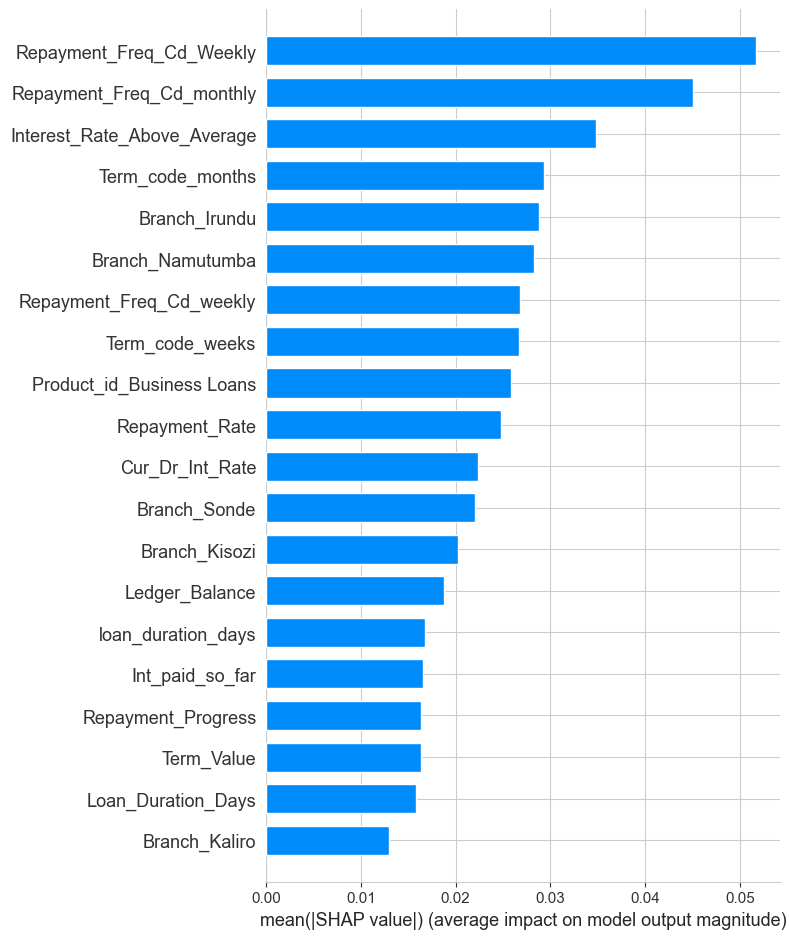

In [215]:
shap.summary_plot(
    shap_values.values[:, :, 1],  # class 1 = default
    X_test,
    plot_type="bar"
)

**Key Takeaway:**

- Repayment frequency (especially weekly) and high interest rates are the dominant factors influencing the model's predictions. Branch and loan term also play significant roles.
- This aligns well with the Random Forest (Tuned) being the best model — it effectively captures these non-linear patterns.

### Full SHAP plot

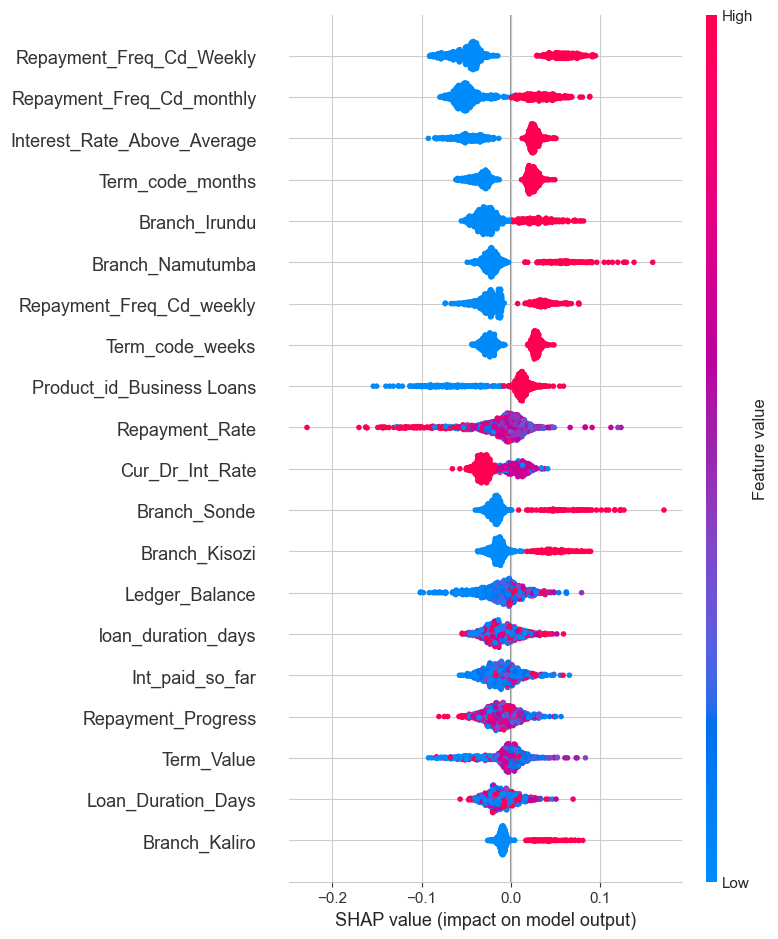

In [217]:
shap.summary_plot(
    sv,
    X_test
)